# Taller de Imputación para Series de Tiempo

## Importar Librerías

Se importan las librerías esenciales para facilitar el análisis que abarca la carga de datos, la evaluación estadística, la visualización, la transformación de datos, la fusión y la unión.

In [26]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import numpy as np
from scipy.stats import shapiro
from scipy.stats import ks_2samp
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

## Lectura de Datos

La base de datos fue importada directamente desde GitHub utilizando pandas, facilitando el acceso a los datos sin necesidad de descargas manuales intermedias.

In [28]:
url2 = "https://raw.githubusercontent.com/Kalbam/Datos/refs/heads/main/ts_imputacion_multivariada_masNA.csv"
df = pd.read_csv(url2)

Se muestran las primeras filas del DataFrame.

In [29]:
df.head()

,fecha,temperatura,humedad,lluvia_mm,precio,ventas,energia_kwh,sensor_A,sensor_B
0,2023-01-01,NaN,60.67,0.00,99.68,527.2,NaN,NaN,51.647
1,2023-01-02,NaN,48.96,0.00,100.50,493.7,120.04,50.476,48.778
2,2023-01-03,NaN,48.73,0.00,100.86,487.7,119.11,52.349,48.953
3,2023-01-04,NaN,57.13,0.00,101.74,512.8,120.71,NaN,49.383
4,2023-01-05,NaN,NaN,2.79,101.77,477.4,119.39,NaN,46.964


Se muestran las últimas filas del DataFrame.

In [30]:
df.tail()

,fecha,temperatura,humedad,lluvia_mm,precio,ventas,energia_kwh,sensor_A,sensor_B
726,2024-12-27,22.42,NaN,0.00,109.78,584.7,155.87,58.668,56.905
727,2024-12-28,18.58,NaN,0.00,110.42,579.7,159.93,58.839,58.212
728,2024-12-29,17.39,NaN,3.22,NaN,552.8,160.03,NaN,61.064
729,2024-12-30,20.27,NaN,0.05,109.93,590.8,154.21,59.731,60.774
730,2024-12-31,16.83,NaN,2.22,109.52,616.8,160.19,61.187,61.262


Se emplea el método `df.info()` para evaluar la estructura y calidad inicial del dataset. Este análisis revela información sobre la composición de los datos, incluyendo el número total de registros (filas) y variables (columnas), los tipos de datos asociados a cada campo (como objetos, enteros o valores flotantes), y la cantidad de valores no nulos por columna.

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   fecha        731 non-null    object 
 1   temperatura  624 non-null    float64
 2   humedad      616 non-null    float64
 3   lluvia_mm    731 non-null    float64
 4   precio       658 non-null    float64
 5   ventas       586 non-null    float64
 6   energia_kwh  671 non-null    float64
 7   sensor_A     612 non-null    float64
 8   sensor_B     635 non-null    float64
dtypes: float64(8), object(1)
memory usage: 51.5+ KB


**Interpretación**

**1. Dimensión del Dataset:**
- **731 entradas (filas):** El dataset abarca **731 registros** (aproximadamente 2 años de datos diarios).
- **9 columnas:** Variables disponibles para análisis.

**2. Problemas Principales Identificados:**

**A. Datos Faltantes Significativos:**
- La columna **`ventas`** tiene la mayor de valores faltantes.
- **`humedad`** y **`temperatura`** también presentan problemas considerables.
- Solo **`fecha`** y **`lluvia_mm`** están completas al 100%.

**B. Tipo de Datos:**
- La columna **`fecha`** está como `object` (debe convertirse a `datetime`)
- Todas las demás columnas son numéricas (`float64`)

**Conclusión:** El dataset tiene una estructura temporal con problemas significativos de datos faltantes que requerirán técnicas robustas de imputación antes de cualquier análisis avanzado.

### Variables Númericas

Se genera una tabla resumen de las variables númericas.

In [32]:
df.describe()

,temperatura,humedad,lluvia_mm,precio,ventas,energia_kwh,sensor_A,sensor_B
count,624.000000,616.000000,731.000000,658.000000,586.000000,671.000000,612.000000,635.000000
mean,18.004904,59.708506,1.754501,102.162264,544.198464,141.981297,54.918033,53.407631
std,6.639764,8.938622,1.719964,3.374867,34.067847,11.701740,3.288326,3.586204
min,4.330000,40.610000,0.000000,94.830000,464.900000,117.940000,46.864000,45.033000
25%,11.897500,51.695000,0.000000,99.670000,517.500000,131.500000,52.488750,50.588500
50%,18.070000,59.665000,1.410000,101.975000,545.100000,141.920000,54.953000,53.424000
75%,24.215000,67.520000,2.900000,104.372500,571.050000,151.335000,57.345250,56.113000
max,30.160000,77.100000,7.650000,111.310000,642.700000,165.080000,62.362000,61.743000


**Interpretación**

**1. Temperatura**
- **Rango amplio:** 4.33°C a 30.16°C (amplitud de 25.83°C)
- **Media:** 18.00°C ± 6.64°C (desviación estándar moderada-alta)
- **Distribución:** Aparentemente simétrica (media ≈ mediana = 18.07°C)

**2. Humedad**
- **Rango típico:** 40.61% a 77.10%
- **Media:** 59.71% ± 8.94% (variabilidad moderada)
- **Distribución:** Simétrica (media ≈ mediana = 59.67%)

**3. Lluvia (mm)**
- **Distribución sesgada:** Media (1.75) > Mediana (1.41)
- **Días sin lluvia:** 25% de los días (percentil 25 = 0.0)
- **Eventos extremos:** Máximo de 7.65 mm (posibles tormentas)

**4. Precio**
- **Rango estrecho:** 94.83 a 111.31 (amplitud de 16.48)
- **Estabilidad:** Baja variabilidad (std = 3.37)
- **Distribución:** Simétrica (media ≈ mediana ≈ 102)

**5. Ventas**
- **Rango moderado:** 464.9 a 642.7 (amplitud de 177.8)
- **Variabilidad:** Media 544.20 ± 34.07 (coeficiente de variación: 6.3%)
- **Distribución:** Aparentemente normal (media ≈ mediana)

**6. Energía (kWh)**
- **Consumo estable:** 117.94 a 165.08 kWh
- **Variabilidad moderada:** Media 141.98 ± 11.70
- **Distribución:** Simétrica (media ≈ mediana)

**7. Sensores A y B**
- **Sensor A:** Media 54.92 ± 3.29 (más estable)
- **Sensor B:** Media 53.41 ± 3.59 (ligeramente más variable)
- **Ambos** muestran distribuciones simétricas

## Valores Nulos

Para cuantificar la magnitud de datos ausentes en cada columna, se calculó el porcentaje de valores nulos y el conteo de esta manera podemos identificar variables críticas que requieren intervención prioritaria en el proceso de limpieza.

In [33]:
total = len(df)
null_counts = df.isna().sum()
null_percent = (null_counts / total) * 100


missing_summary_2 = pd.DataFrame({
    "Nulos": null_counts,
    "Porcentaje (%)": null_percent.round(2)
})

print("=== Resumen de valores nulos ===")
print(missing_summary_2)

=== Resumen de valores nulos ===
             Nulos  Porcentaje (%)
fecha            0            0.00
temperatura    107           14.64
humedad        115           15.73
lluvia_mm        0            0.00
precio          73            9.99
ventas         145           19.84
energia_kwh     60            8.21
sensor_A       119           16.28
sensor_B        96           13.13


**Interpretación**

**Variables Completas (0% nulos):**
- **`fecha`**: 0% - Columna temporal completa (esencial para análisis de series de tiempo)
- **`lluvia_mm`**: 0% - Registro pluviométrico completo, variable confiable

**Nulos Moderados (8-13%):**
- **`energia_kwh`**: 8.21% (60 nulos) - **Menor problema**
- **`sensor_B`**: 13.13% (96 nulos) - Moderado
- **`precio`**: 9.99% (73 nulos) - Moderado

**Nulos Severos (14-16%):**
- **`temperatura`**: 14.64% (107 nulos) - Problema significativo
- **`humedad`**: 15.73% (115 nulos) - Problema significativo  
- **`sensor_A`**: 16.28% (119 nulos) - **Problema grave**

**Nulos Críticos (>19%):**
- **`ventas`**: 19.84% (145 nulos) - **Variable más crítica**, casi 1 de cada 5 registros faltante

**Conclusión:**
El dataset requiere **procesamiento robusto de valores faltantes** antes de cualquier análisis, con especial atención a las variables de ventas y sensores que presentan los mayores problemas de completitud.

### Gráfico de Barras de los Valores Nulos

Este gráfico visualiza el porcentaje de datos faltantes en cada variable del dataset, permitiendo identificar de un vistazo las columnas que requieren mayor atención en el proceso de limpieza de datos.

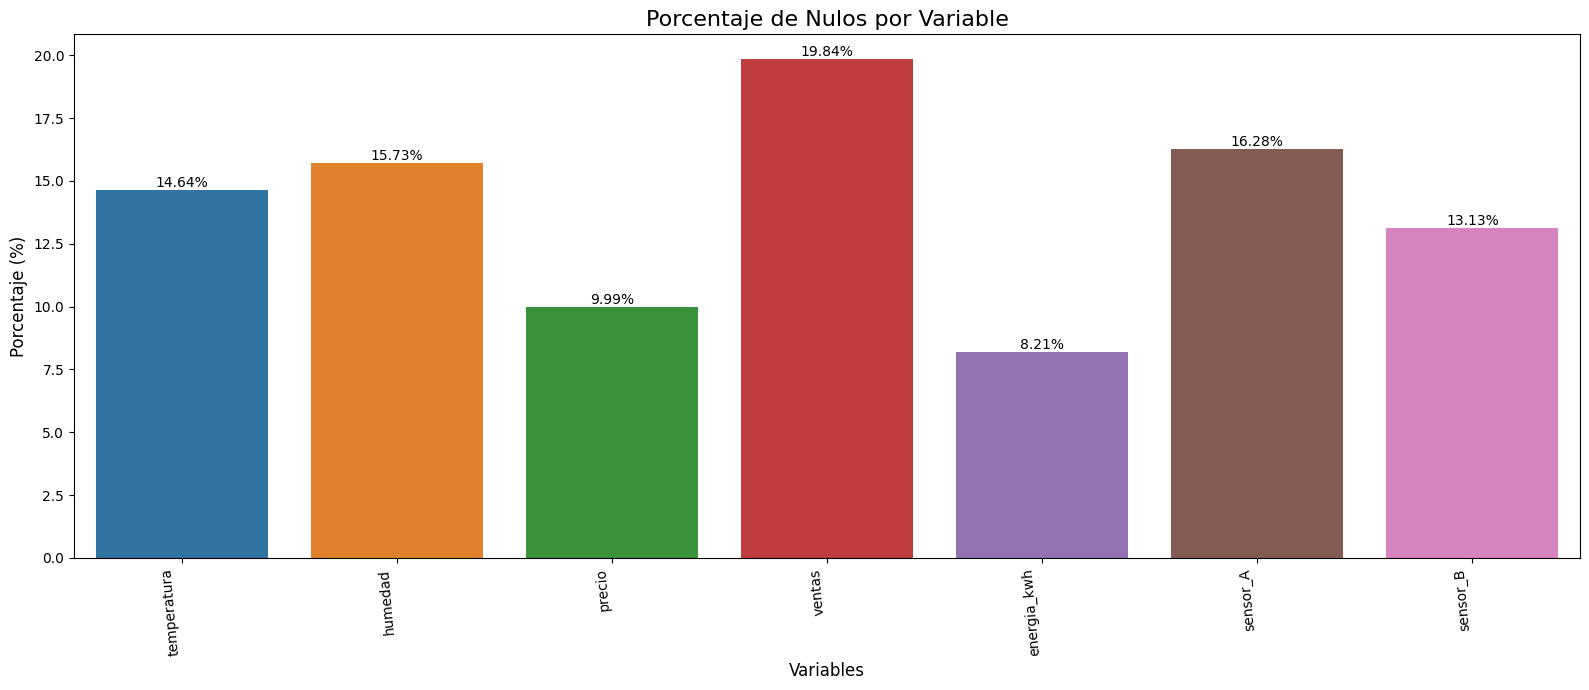

In [34]:
missing_vars_2 = missing_summary_2[missing_summary_2["Nulos"] > 0]

plt.figure(figsize=(16, 7))
bars = sns.barplot(x=missing_vars_2.index, y=missing_vars_2["Porcentaje (%)"])
plt.title("Porcentaje de Nulos por Variable", fontsize=16)
plt.ylabel("Porcentaje (%)", fontsize=12)
plt.xlabel("Variables", fontsize=12)
plt.xticks(rotation=95, ha="right")

for bar in bars.patches:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Métodos de imputación para series de Tiempo (Investigación)

La imputación de datos faltantes es un paso crítico en el preprocesamiento de series de tiempo. La elección del método adecuado depende de la naturaleza de los datos (tendencia, estacionalidad, patrón de missingness) y el objetivo del análisis. A continuación, se presenta una clasificación y descripción de los métodos más comunes.

### 1. Métodos Simples (Basados en Vecindad)

Estos métodos son intuitivos y de rápida implementación, ideales para una primera aproximación o cuando el patrón de datos faltantes es pequeño.

#### **Forward Fill (LOCF - Last Observation Carried Forward)**
*   **¿Qué es?** Imputa un valor faltante con el **último valor válido observado** inmediatamente anterior en la serie.
*   **¿Cuándo usarlo?** Es apropiado cuando se asume que el valor de la variable se mantiene constante hasta la próxima medición. Ejemplos típicos incluyen: lecturas de sensores que se actualizan solo al cambiar, el precio de una acción entre transacciones o el nivel de inventario.
*   **Ventajas:** Extremadamente simple y rápido de calcular. Preserva el último valor conocido.
*   **Desventajas:** Puede subestimar la variabilidad real de los datos y aplanar tendencias. Introduce un sesgo a la baja (o al alza) si la serie tiene una tendencia clara. No es recomendable para brechas largas de datos faltantes.

#### **Backward Fill (NOCB - Next Observation Carried Backward)**
*   **¿Qué es?** El opuesto a Forward Fill. Imputa un valor faltante con el **próximo valor válido observado** inmediatamente posterior en la serie.
*   **¿Cuándo usarlo?** Su uso es menos común, pero puede aplicarse en contextos donde un evento futuro "explica" el valor pasado, como en registros que se completan de forma retrospectiva.
*   **Desventajas:** Su mayor limitación es que **utiliza información del futuro** para imputar el pasado, lo que genera "fugas de datos" (*data leakage*) y hace que el conjunto de datos sea inválido para entrenar modelos predictivos, ya estos no tendrían acceso a esa información futura en tiempo real.

---

### 2. Métodos de Interpolación

Los métodos de interpolación intentan estimar los valores faltantes modelando la trayectoria entre los puntos de datos conocidos, siendo más sofisticados que los métodos simples.

#### **Interpolación Lineal**
*   **¿Qué es?** Conecta dos puntos de datos conocidos (anterior y posterior al faltante) con una línea recta y toma el valor de esa línea en el punto faltante.
*   **¿Cuándo usarlo?** Es efectivo cuando se presume que la serie tiene un comportamiento lineal entre observaciones. Es un buen equilibrio entre simplicidad y rendimiento.
*   **Desventajas:** No captura tendencias no lineales, estacionalidad o patrones complejos.

#### **Interpolación Polinomial**
*   **¿Qué es?** Ajusta un polinomio de grado `n` (e.g., cuadrático, cúbico) a los puntos de datos adyacentes para estimar el valor faltante.
*   **¿Cuándo usarlo?** Útil para series con un comportamiento curvilíneo pronunciado entre los puntos de referencia.
*   **Desventajas:** Puede ser muy propenso al **sobreajuste** (*overfitting*), especialmente con polinomios de alto grado, generando oscilaciones poco realistas.

#### **Interpolación por Spline Cúbico**
*   **¿Qué es?** Un método avanzado que ajusta una serie de polinomios cúbicos individuales (suaves y diferenciables) a cada segmento de la serie entre puntos conocidos, asegurando que la curva total sea suave.
*   **¿Cuándo usarlo?** Ideal para series de tiempo con patrones no lineales y suaves, donde se busca una aproximación más precisa y estéticamente coherente que la interpolación lineal.
*   **Desventajas:** Computacionalmente más costosa. Puede tener un comportamiento errático en los extremos (*extrapolation*) o si los datos tienen mucho ruido.

---

### 3. Métodos Estadísticos y basados en Modelos

Estos enfoques utilizan la estructura inherente de los datos (como la tendencia o estacionalidad) para realizar imputaciones más robustas.

#### **Imputación con Media/Mediana Móvil**
*   **¿Qué es?** Rellena el valor faltante con la media o mediana de una ventana de `k` observaciones anteriores (o centrada) alrededor del punto faltante.
*   **¿Cuándo usarlo?** Ayuda a suavizar el ruido y es simple de implementar. La mediana es robusta a outliers.
*   **Desventajas:** Introduce un ligero retraso (*lag*) y suaviza la serie, reduciendo la variabilidad real. Al igual que Backward Fill, una ventana centrada usa información futura.

#### **Interpolación Estacional**
*   **¿Qué es?** Imputa el valor faltante basándose en el patrón estacional de la serie. Por ejemplo, para un dato faltante a las 3 PM de un día, se usa el promedio de los valores a las 3 PM de los días anteriores o de la misma semana.
*   **¿Cuándo usarlo?** Es **extremadamente útil y preciso** para series con una fuerte componente estacional (diaria, semanal, anual), como la demanda de energía eléctrica, el tráfico web o las temperaturas.
*   **Desventajas:** Requiere que se identifique y defina correctamente el período estacional de la serie.

#### **Imputación basada en Modelos (ARIMA, Prophet, etc.)**
*   **¿Qué es?** Utiliza modelos predictivos de series de tiempo (como ARIMA, Exponential Smoothing o Prophet) entrenados con los datos disponibles para predecir (imputar) los valores faltantes.
*   **¿Cuándo usarlo?** Para problemas complejos con grandes brechas de datos, tendencias no lineales y múltiples estacionalidades. Es uno de los métodos más potentes y precisos.
*   **Desventajas:** Computacionalmente intensivo. Requiere amplio conocimiento para seleccionar, configurar y validar el modelo correcto. Existe el riesgo de sobreajuste si no se regulariza adecuadamente.

### **Conclusión**
No existe un único método óptimo para todos los casos. La selección debe basarse en un análisis exploratorio de la serie (para identificar tendencia, estacionalidad y el patrón de datos faltantes) y en la naturaleza del problema. Lo recomendado es probar varios métodos y evaluar su impacto en el análisis o modelo final mediante técnicas de validación. Para los casos más críticos, los métodos basados en modelos suelen ofrecer los mejores resultados.

## **Forward Fill (LOCF - Last Observation Carried Forward)**

Para evaluar la efectividad de la imputación, primero es necesario preparar el DataFrame estableciendo la columna de fecha como índice y luego aplicar el método Forward Fill a las variables numéricas seleccionadas. El siguiente código realiza este proceso y verifica que no queden valores nulos.

In [35]:
from plotly.subplots import make_subplots
df['fecha'] = pd.to_datetime(df['fecha'])
df.set_index('fecha', inplace=True)

variables_a_imputar = ['temperatura', 'humedad', 'precio', 'ventas', 'energia_kwh', 'sensor_A', 'sensor_B']

df_imputado = df.copy()

df_imputado[variables_a_imputar] = df_imputado[variables_a_imputar].fillna(method='ffill')

print("Valores nulos después de la imputación con Forward Fill:")
print(df_imputado[variables_a_imputar].isnull().sum())

Valores nulos después de la imputación con Forward Fill:
temperatura    7
humedad        0
precio         0
ventas         0
energia_kwh    1
sensor_A       1
sensor_B       0
dtype: int64


C:\Users\david\AppData\Local\Temp\ipykernel_4500\1370628207.py:9: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



Una vez aplicada la imputación, es crucial visualizar comparativamente los datos originales con los imputados para evaluar visualmente la calidad del método. El siguiente código genera una matriz de subgráficos que permite comparar cada variable antes y después del proceso de imputación.

In [36]:
fig = make_subplots(rows=len(variables_a_imputar), cols=2,
                    subplot_titles=[f'{var} (Original)' for var in variables_a_imputar] +
                                   [f'{var} (Imputado)' for var in variables_a_imputar],
                    horizontal_spacing=0.1, vertical_spacing=0.05,
                    shared_xaxes=True)

for i, var in enumerate(variables_a_imputar):

    fig.add_trace(go.Scatter(x=df.index, y=df[var], mode='lines', name=f'Original: {var}'),
                  row=i+1, col=1)

    fig.add_trace(go.Scatter(x=df_imputado.index, y=df_imputado[var], mode='lines', name=f'Imputado: {var}'),
                  row=i+1, col=2)

fig.update_layout(height=400 * len(variables_a_imputar), showlegend=True,
                  title_text="Comparación de Series de Tiempo: Original vs. Imputada con Forward Fill",
                  template='plotly_white')

fig.show()

## **Backward Fill (NOCB - Next Observation Carried Backward)**

Para comparar la efectividad de diferentes métodos de imputación, se procede a aplicar la técnica de Backward Fill (NOCB) al mismo conjunto de variables. Este método propaga el siguiente valor válido observado hacia atrás para llenar los huecos.

In [37]:
from plotly.subplots import make_subplots

variables_a_imputar = ['temperatura', 'humedad', 'precio', 'ventas', 'energia_kwh', 'sensor_A', 'sensor_B']

df_bfill = df.copy()

df_bfill[variables_a_imputar] = df_bfill[variables_a_imputar].fillna(method='bfill')

print("Resumen de valores nulos después de la imputación con Backward Fill:")
print(df_bfill[variables_a_imputar].isnull().sum())

Resumen de valores nulos después de la imputación con Backward Fill:
temperatura    0
humedad        7
precio         0
ventas         0
energia_kwh    0
sensor_A       0
sensor_B       0
dtype: int64


C:\Users\david\AppData\Local\Temp\ipykernel_4500\1028864607.py:7: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



Una vez aplicada la imputación, es crucial visualizar comparativamente los datos originales con los imputados para evaluar visualmente la calidad del método. El siguiente código genera una matriz de subgráficos que permite comparar cada variable antes y después del proceso de imputación.

In [38]:
fig = make_subplots(rows=len(variables_a_imputar), cols=2,
                    subplot_titles=[f'{var} (Original)' for var in variables_a_imputar] +
                                   [f'{var} (Imputado)' for var in variables_a_imputar],
                    horizontal_spacing=0.1, vertical_spacing=0.05,
                    shared_xaxes=True)

for i, var in enumerate(variables_a_imputar):

    fig.add_trace(go.Scatter(x=df.index, y=df[var], mode='lines', name=f'Original: {var}'),
                  row=i + 1, col=1)


    fig.add_trace(go.Scatter(x=df_bfill.index, y=df_bfill[var], mode='lines', name=f'Imputado: {var}'),
                  row=i + 1, col=2)

fig.update_layout(height=400 * len(variables_a_imputar), showlegend=True,
                  title_text="Comparación de Series de Tiempo: Original vs. Imputada con Backward Fill",
                  template='plotly_white')

fig.show()

## **Interpolación Lineal**

Para mejorar la precisión de la imputación capturando la tendencia entre puntos de datos adyacentes, se aplica el método de interpolación lineal. Esta técnica calcula valores intermedios a lo largo de una línea recta entre observaciones conocidas, proporcionando una estimación más suave que los métodos de forward/backward fill.

In [39]:
from plotly.subplots import make_subplots

variables_a_imputar = ['temperatura', 'humedad', 'precio', 'ventas', 'energia_kwh', 'sensor_A', 'sensor_B']

df_interpolado = df.copy()

df_interpolado[variables_a_imputar] = df_interpolado[variables_a_imputar].interpolate(method='linear')

print("Resumen de valores nulos después de la imputación con Interpolación Lineal:")
print(df_interpolado[variables_a_imputar].isnull().sum())

Resumen de valores nulos después de la imputación con Interpolación Lineal:
temperatura    7
humedad        0
precio         0
ventas         0
energia_kwh    1
sensor_A       1
sensor_B       0
dtype: int64


Una vez aplicada la imputación, es crucial visualizar comparativamente los datos originales con los imputados para evaluar visualmente la calidad del método. El siguiente código genera una matriz de subgráficos que permite comparar cada variable antes y después del proceso de imputación.

In [40]:
fig = make_subplots(rows=len(variables_a_imputar), cols=2,
                    subplot_titles=[f'{var} (Original)' for var in variables_a_imputar] +
                                   [f'{var} (Imputado)' for var in variables_a_imputar],
                    horizontal_spacing=0.1, vertical_spacing=0.05,
                    shared_xaxes=True)

for i, var in enumerate(variables_a_imputar):

    fig.add_trace(go.Scatter(x=df.index, y=df[var], mode='lines', name=f'Original: {var}'),
                  row=i + 1, col=1)

    fig.add_trace(go.Scatter(x=df_interpolado.index, y=df_interpolado[var], mode='lines', name=f'Imputado: {var}'),
                  row=i + 1, col=2)

fig.update_layout(height=400 * len(variables_a_imputar), showlegend=True,
                  title_text="Comparación de Series de Tiempo: Original vs. Imputada con Interpolación Lineal",
                  template='plotly_white')

fig.show()

## **Forward Fill y Backward Fill Combinados**

Para garantizar la eliminación completa de todos los valores nulos, se implementa una estrategia combinada que aplica primero Forward Fill (para propagar los últimos valores válidos hacia adelante) y luego Backward Fill (para cubrir los valores restantes al inicio de la serie con los primeros valores disponibles). Este enfoque asegura un dataset completamente imputado.

In [41]:
variables_a_imputar = ['temperatura', 'humedad', 'precio', 'ventas', 'energia_kwh', 'sensor_A', 'sensor_B']

df_final_imputado = df.copy()

df_final_imputado[variables_a_imputar] = df_final_imputado[variables_a_imputar].fillna(method='ffill')

df_final_imputado[variables_a_imputar] = df_final_imputado[variables_a_imputar].fillna(method='bfill')

print("Valores nulos después de la imputación combinada (ffill y bfill):")
print(df_final_imputado[variables_a_imputar].isnull().sum())

Valores nulos después de la imputación combinada (ffill y bfill):
temperatura    0
humedad        0
precio         0
ventas         0
energia_kwh    0
sensor_A       0
sensor_B       0
dtype: int64


C:\Users\david\AppData\Local\Temp\ipykernel_4500\1245326820.py:5: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

C:\Users\david\AppData\Local\Temp\ipykernel_4500\1245326820.py:7: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

